# Analyse PE samples

In [2]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.size'] = 14

from src.io import param_load
from src.analysis import (
    sampled_params_from_config,
    load_samples,
    plot_log_like,
    cut_samples_autocorr,
    filter_lost_walkers,
    corner_plot,
    plot_sky_position,
    plot_chain_convergence,
    plot_covariance_evolution,
    plot_gelman_rubin,
    plot_seaborn_diagnostics,
)

## Define samples

In [3]:
# define PE run settings
test_case  = ''    # which test case to load: '', '_amps_off', '_evolution_primary_off'
inj = '1PA'
rec = '1PA'
eps = 'e-5'
discard= 1400   # burn-in iterations to discard

# Post-processing
do_filter_lost   = False  # remove lost walkers
do_thin          = False  # thin by integrated auto-correlation time to exclude correlated samples
exclude_sky      = False  # exclude sky-angle params from the intrinsic corner plot

# Threshold for lost walker detection 
# This only applies to the cold chain
lost_lower_bound = -30.0

# Colour for this run's posterior in overlay plots
posterior_color  = 'steelblue'

In [4]:
if test_case is not None:
    config = param_load(f'./config/config_test{test_case}.yaml')
else:
    config = param_load(f'./config/config_inj_{inj}_rec_{rec}_eps_{eps}.yaml')

emri   = config['Injection']['EMRI']
inj_wf = config['Injection']['Waveform']
rec_wf = config['Recovery']['Waveform']

amps_toggle = config['Recovery']['Waveform']['include_1PA_amps']
evolution_primary_toggle = config['Recovery']['Waveform']['evolve_chi1']

print(f"Injection model : {inj_wf['model']}")
print(f"Recovery model  : {rec_wf['model']} \n 1PA amps {amps_toggle}, evolution primary {evolution_primary_toggle}")
print(f"Fixed params    : {config['Sampler'].get('fixed_params', [])}")
print()
print('EMRI injection parameters')
print('=' * 32)
for k, v in emri.items():
    print(f'  {k:<16} {v}')
    
print('=' * 32)
print(f'Mass-ratio m2 / m1= {emri['mu'] / emri['M']:.2e}')

Injection model : 1PAT1R
Recovery model  : 1PAT1R 
 1PA amps True, evolution primary True
Fixed params    : ['x_I0', 'e0']

EMRI injection parameters
  M                1000000.0
  mu               10.0
  a                2e-05
  p0               9.0
  e0               0.0
  x_I0             1.0
  d_L              0.1
  theta_S          0.5689062462243505
  phi_S            3.069569972026508
  theta_K          0.11247032308126413
  phi_K            0.7524383205999023
  Phi_phi0         4.809727148143657
  Phi_theta0       0.635376120342196
  Phi_r0           4.2638433178190684
  chi2             0.9
  z                1
Mass-ratio m2 / m1= 1.00e-05


In [5]:
param_names, true_vals = sampled_params_from_config(config)

print(f'Sampled parameters ({len(param_names)}):')
for name, val in zip(param_names, true_vals):
    print(f'  {name:<16} {val}')

Sampled parameters (13):
  M                1000000.0
  mu               10.0
  a                2e-05
  p0               9.0
  chi2             0.9
  d_L              0.1
  theta_S          0.5689062462243505
  phi_S            3.069569972026508
  theta_K          0.11247032308126413
  phi_K            0.7524383205999023
  Phi_phi0         4.809727148143657
  Phi_theta0       0.635376120342196
  Phi_r0           4.2638433178190684


In [6]:
sampling_dir = f'{os.getcwd()}/sampling_data'
# select sampling files matching test case description
pattern      = os.path.join(sampling_dir, f'SamplingResults_test{test_case}*.h5')
# sort files by timestamp in filename
files        = sorted(glob.glob(pattern))

if not files:
    raise FileNotFoundError(f'No sampling file found matching {pattern}')
# Get last file, assuming this is the one we intend to analyze. 
file_path = files[-1]
print(f'Loading: {file_path}')

# Load samples and log-likelihoods from the HDF5 backend file
samples_per_temp, reader, log_like, (N_iters, N_temps, N_walkers, N_params) = \
    load_samples(file_path, discard=discard)

print(f'Shape: {N_iters} iters  x  {N_temps} temps  x  {N_walkers} walkers  x  {N_params} params')

Loading: /vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/sampling_data/SamplingResults_test_fixedx_I0_1.0_e0_0.0_2026-04-25_19-55-48.h5
Shape: 1201 iters  x  3 temps  x  30 walkers  x  13 params


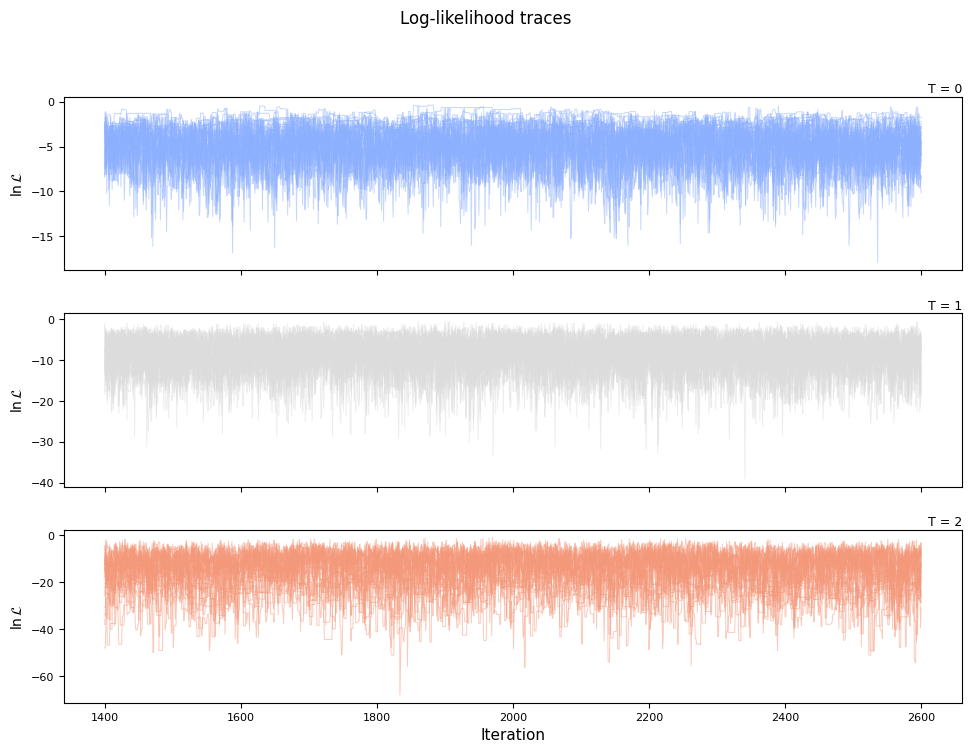

In [7]:
plot_log_like(log_like, temps=list(range(N_temps)), discard=discard)
plt.show()

In [8]:
# if the lgglikelihood shows lost walkers, we filetr these out from the cold chain
if do_filter_lost:
    clean_samples, kept_idx, ll_clean = filter_lost_walkers(
        reader, discard=discard, lower_bound=lost_lower_bound
    )
    # Replace cold-chain samples with the filtered version
    samples_per_temp[0] = clean_samples
    print(f'Cold chain after filtering: {clean_samples.shape}')
else:
    print('Skipping lost-walker filtering.')

Skipping lost-walker filtering.


In [9]:
if do_thin:
    samples_per_temp = cut_samples_autocorr(reader, samples_per_temp, discard=discard)
    print(f'Thinned cold chain: {samples_per_temp[0].shape}')
else:
    print('Skipping autocorrelation thinning.')

Skipping autocorrelation thinning.


### Verify chain convergence
A stable loglikelihood trace indicates that the chains have converged. However, proper convergence diagnostics are needed to confirm this. We plot the loglikelihood trace for the cold chain (T=0) to visually inspect its behavior over iterations. A stable and well-mixed trace suggests good convergence, while trends or large fluctuations point to issues with convergence.

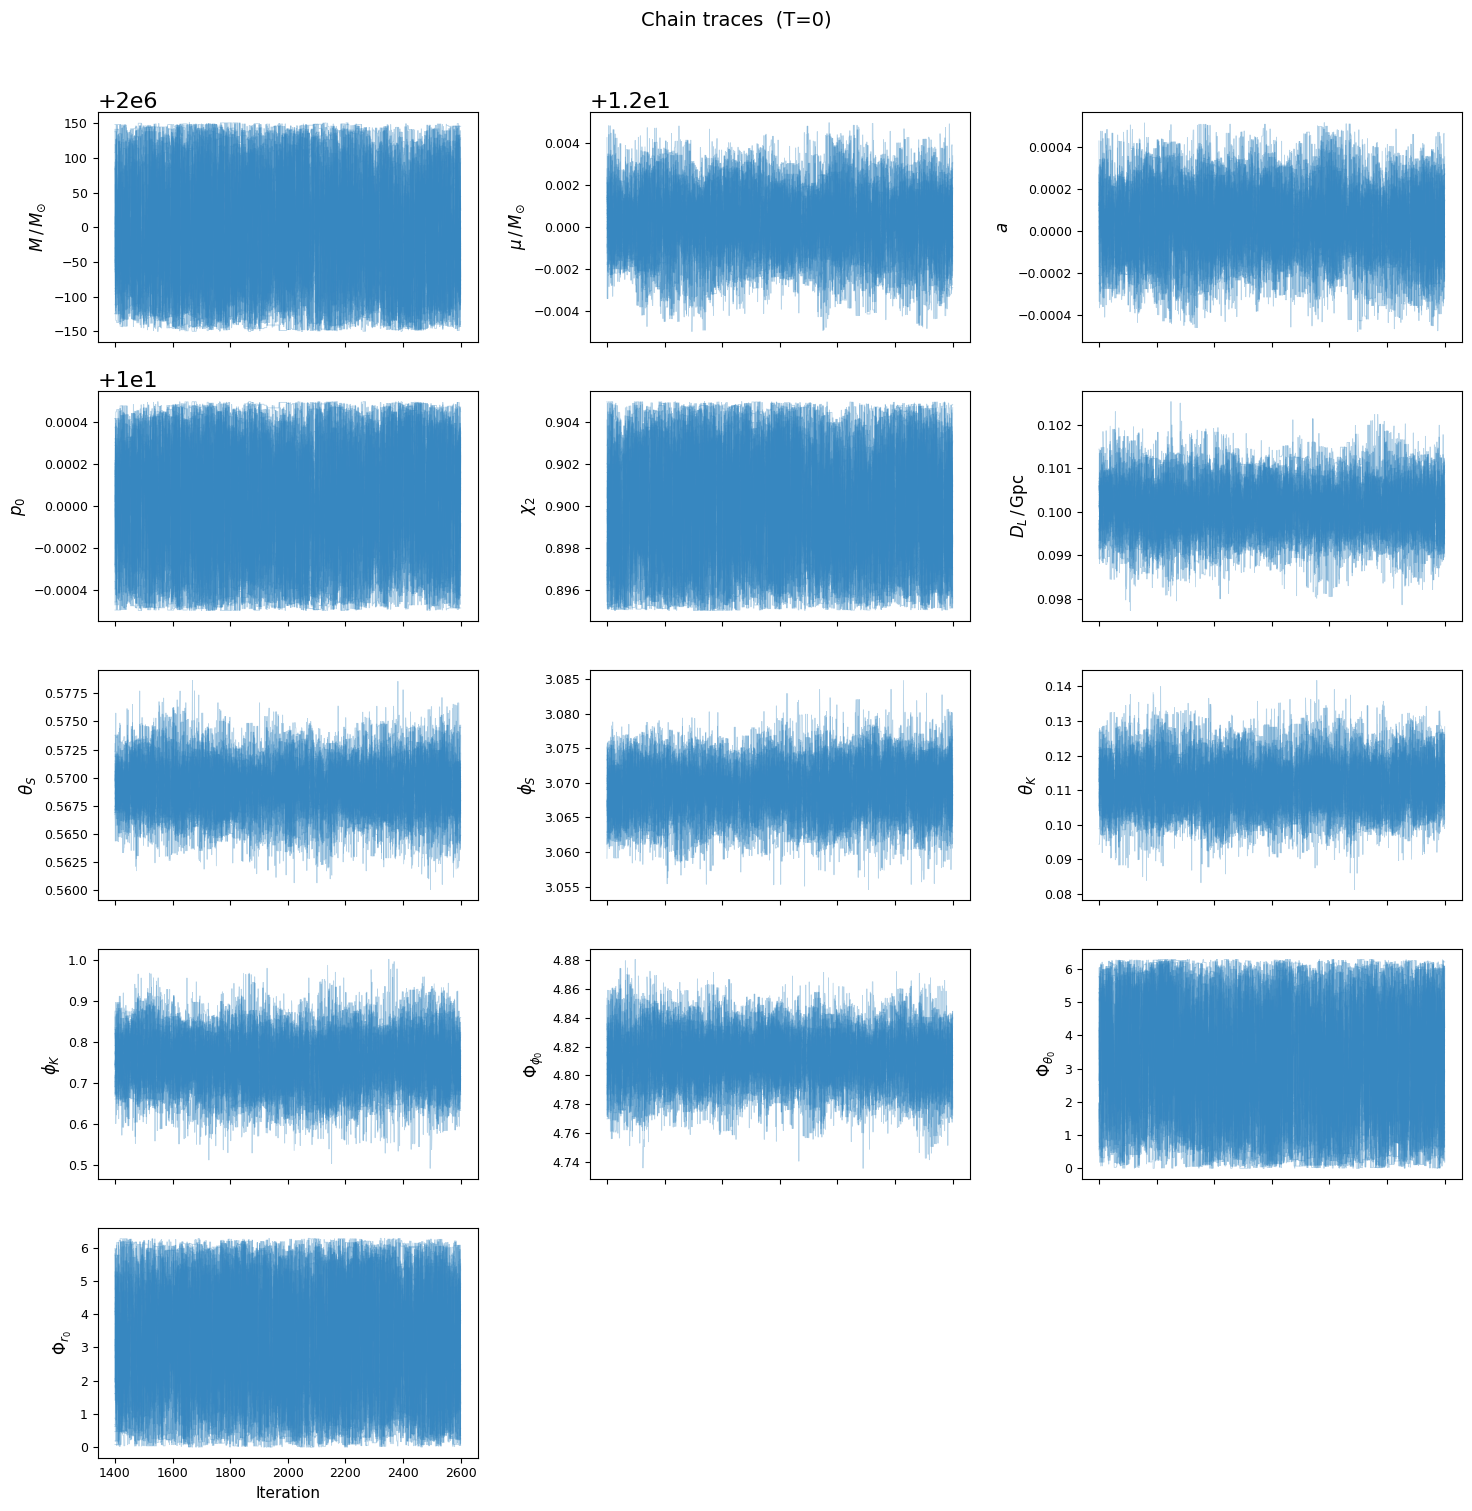

In [10]:
plot_name_traces = f'{os.getcwd()}/Plots/test_{test_case}_traces'

fig = plot_chain_convergence(
    reader, param_names,
    discard=discard, temp=0,
    plot_name=plot_name_traces,
)

## Corner plot
Create corner plot kto inspect the posterior distributions of parameters and their correlations

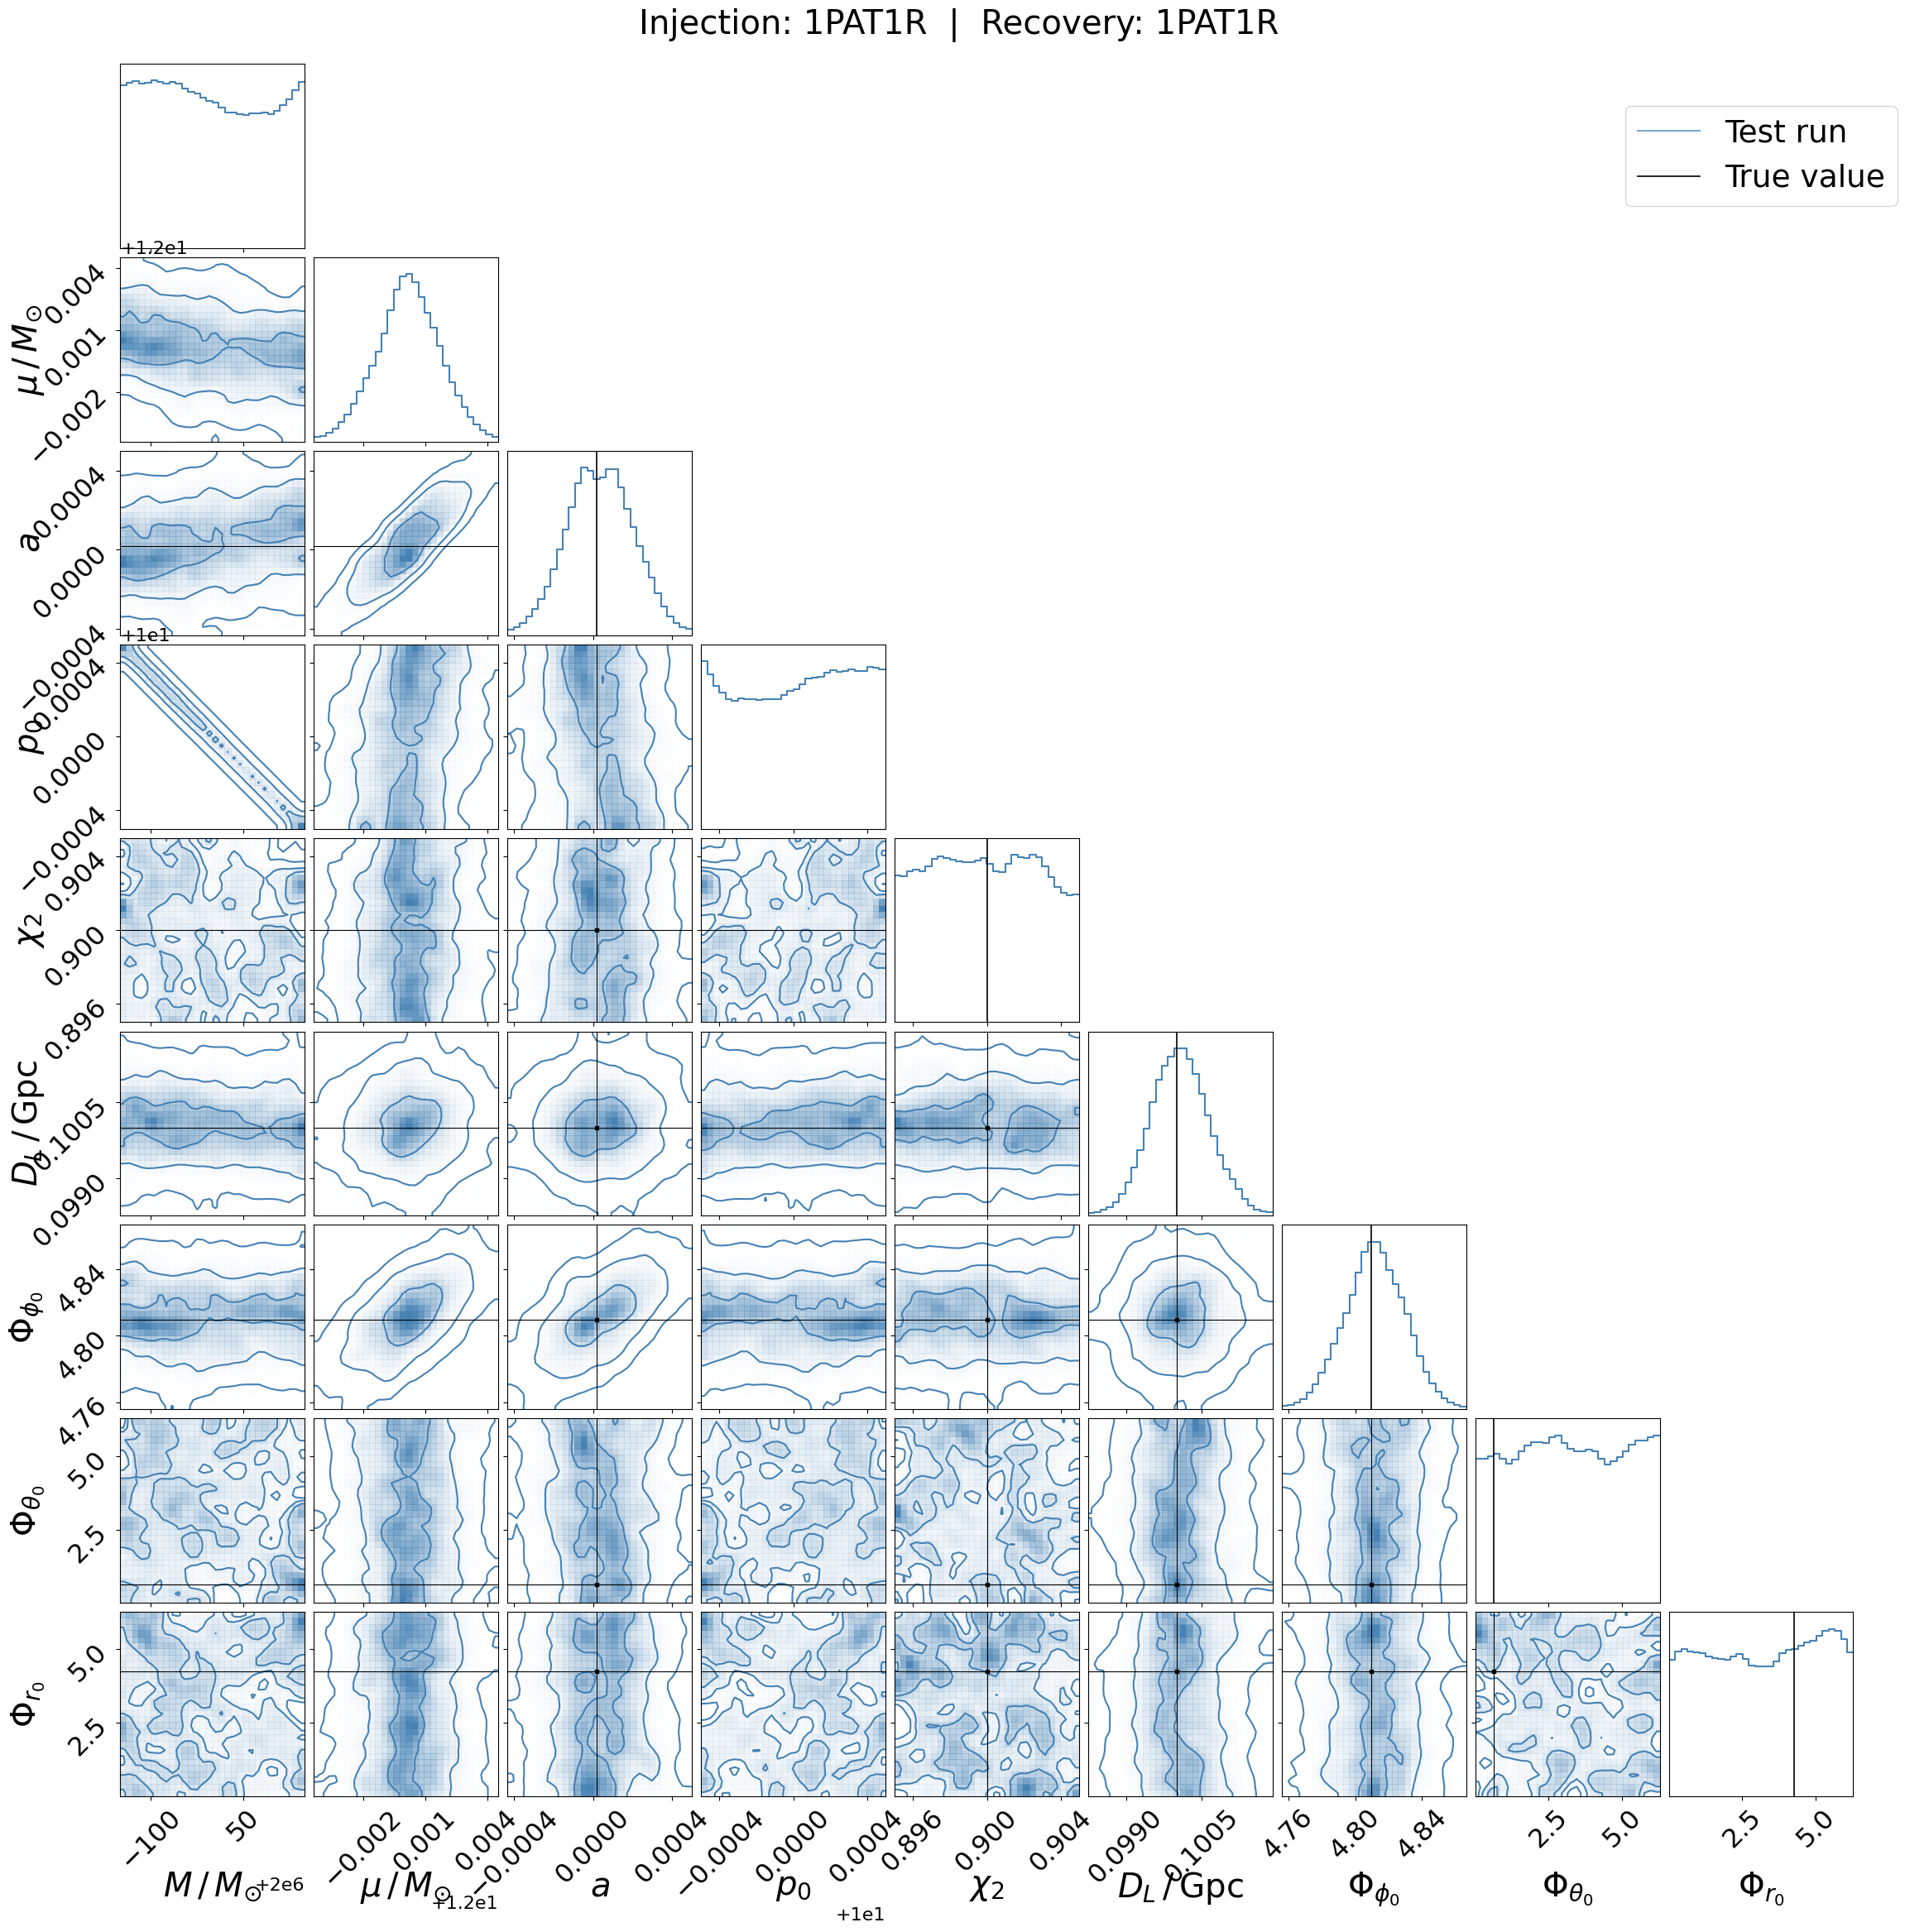

In [11]:
# samples_dict: key = legend label; value = dict with 'color' and 'samples'.
# Add extra entries here to overlay additional posteriors (e.g. higher temps).
samples_dict = {
    'Test run': {
        'color':   posterior_color,
        'samples': samples_per_temp[0],
    },
}

os.makedirs(f'{os.getcwd()}/Plots', exist_ok=True)
plot_name_intrinsic = f'{os.getcwd()}/Plots/test_{test_case}_corner_intrinsic'

fig = corner_plot(
    samples_dict,
    true_vals,
    param_names,
    inj_model=inj_wf['model'],
    rec_model=rec_wf['model'],
    exclude_sky=True,          # intrinsic + phases only
    plot_name=plot_name_intrinsic,
)
plt.show()

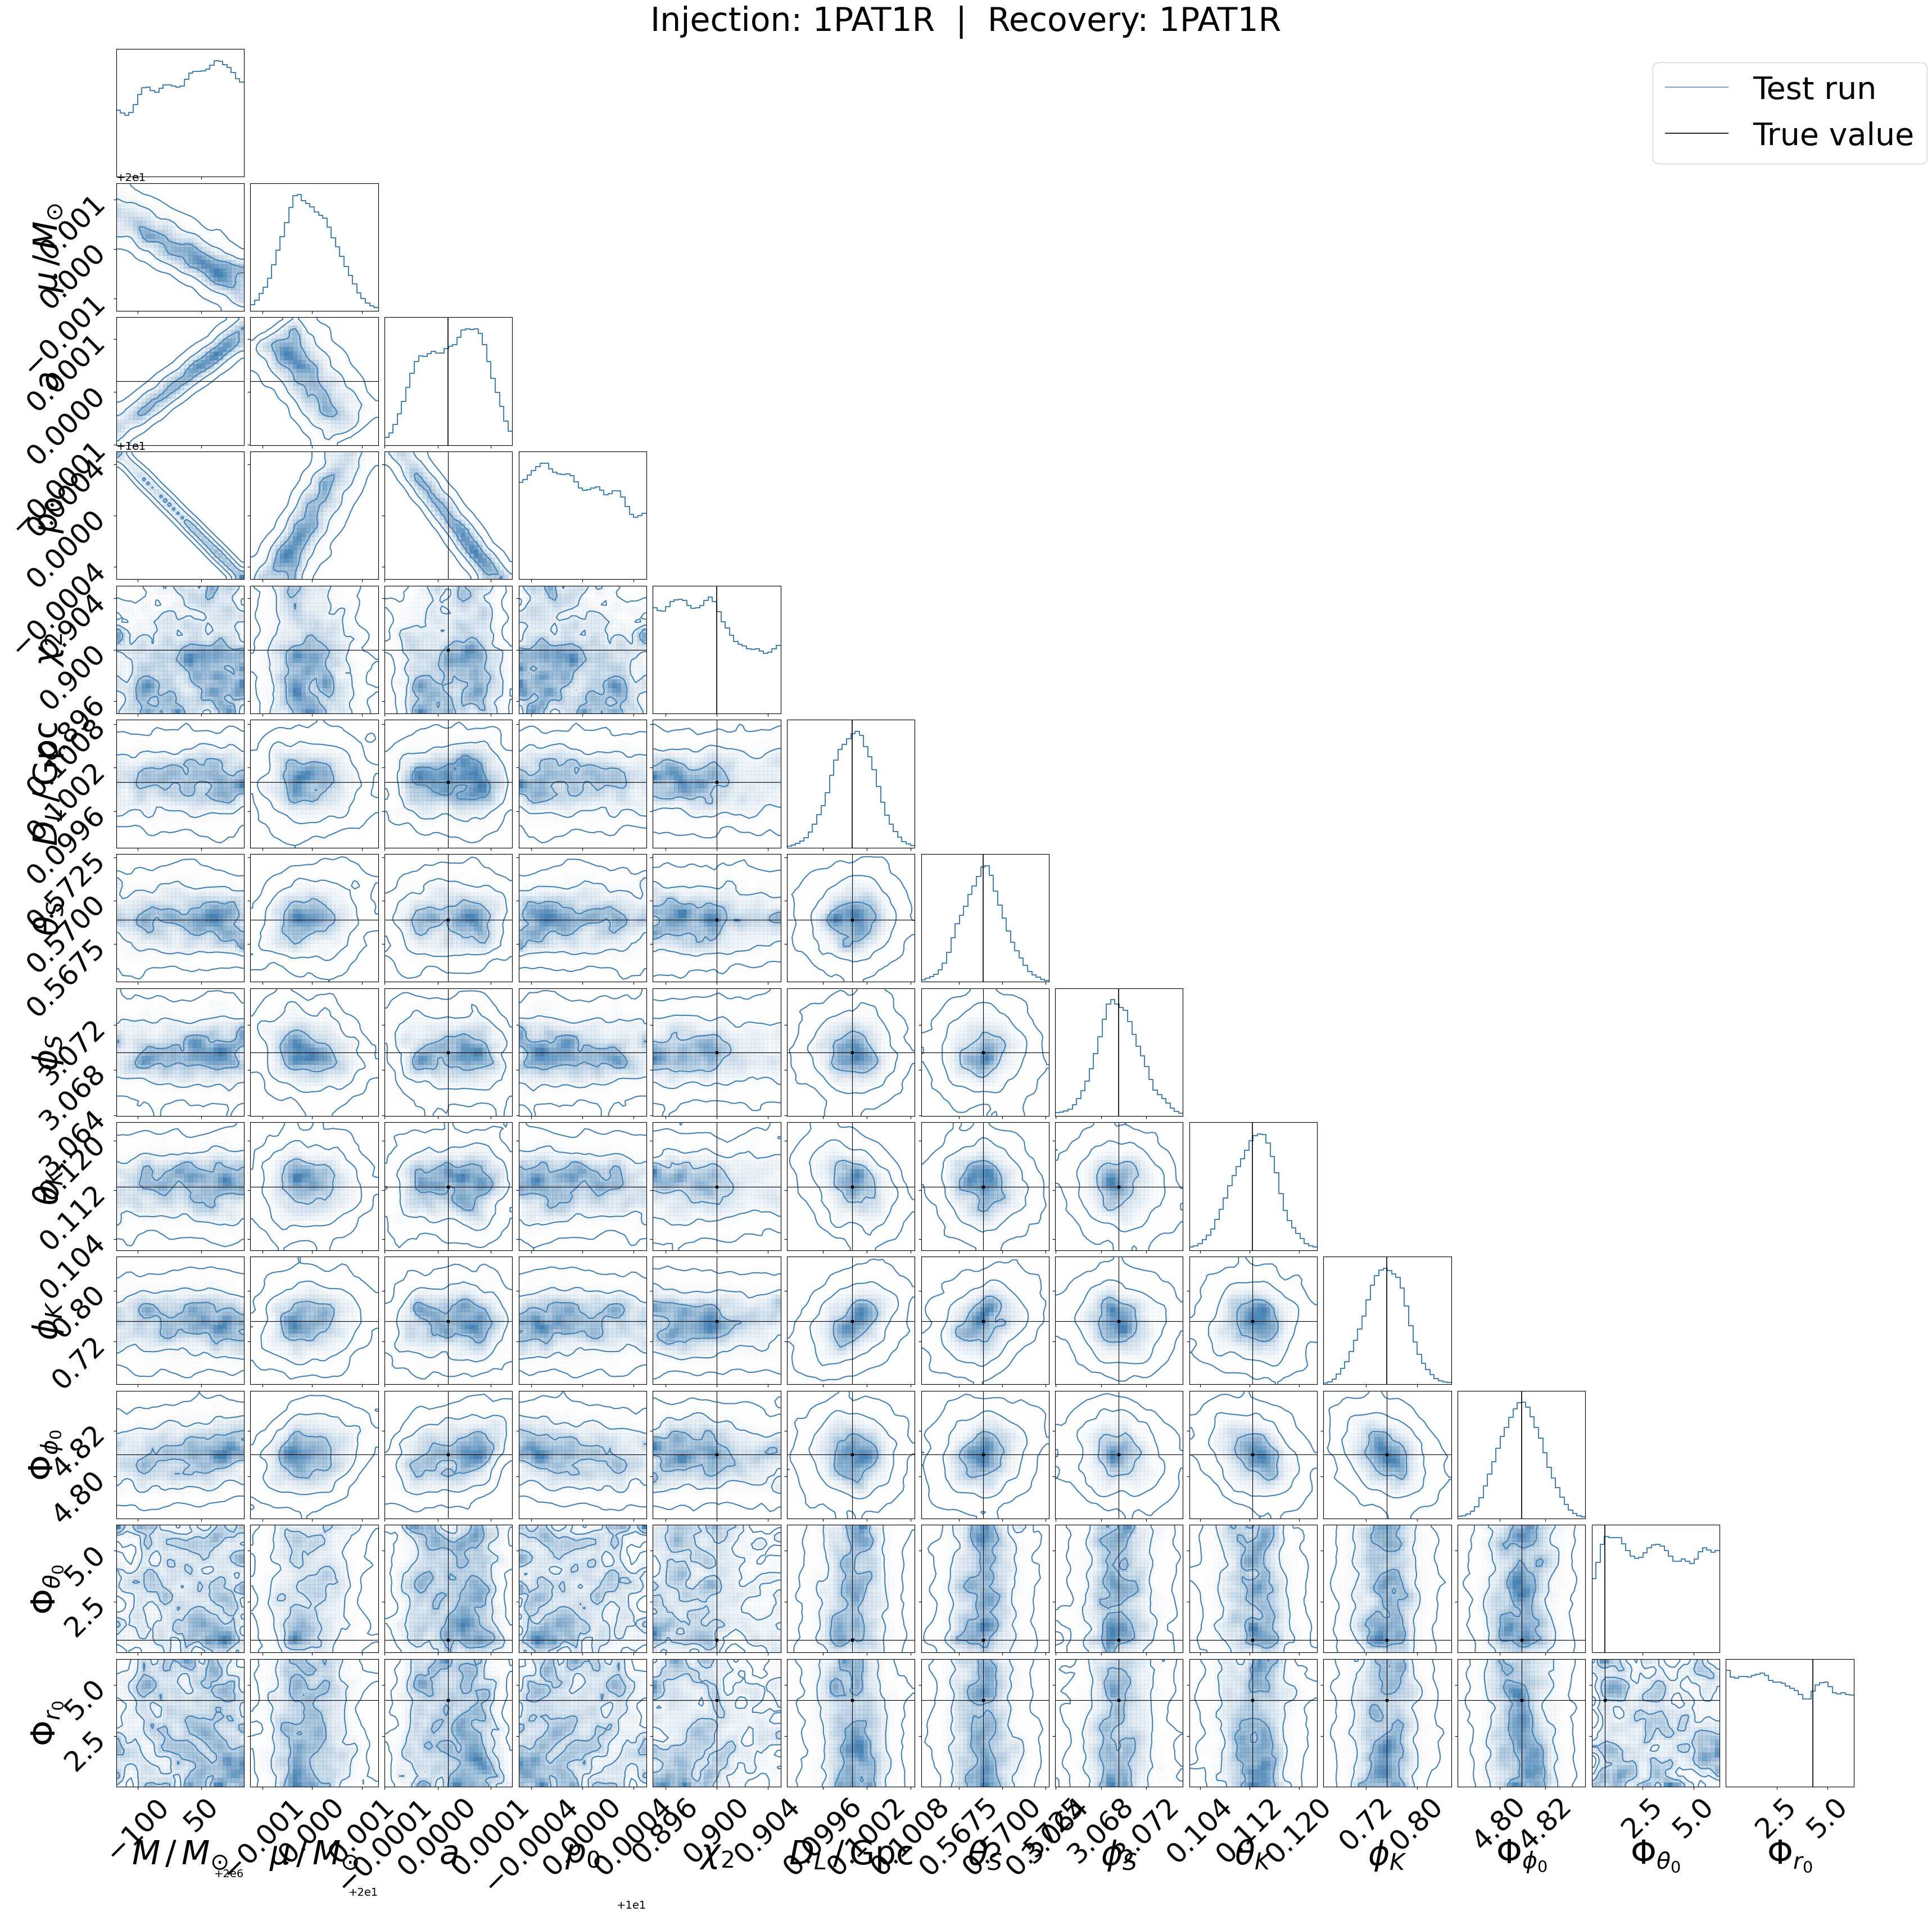

In [35]:
# Full corner plot including sky-angle parameters
plot_name_full = f'{os.getcwd()}/Plots/test_{test_case}_corner_full'

fig = corner_plot(
    samples_dict,
    true_vals,
    param_names,
    inj_model=inj_wf['model'],
    rec_model=rec_wf['model'],
    exclude_sky=False,
    plot_name=plot_name_full,
)
plt.show()

Seems like the semi-latus rectum and primary mass are completely degenerate. Any good reason for this? 

## Sky position

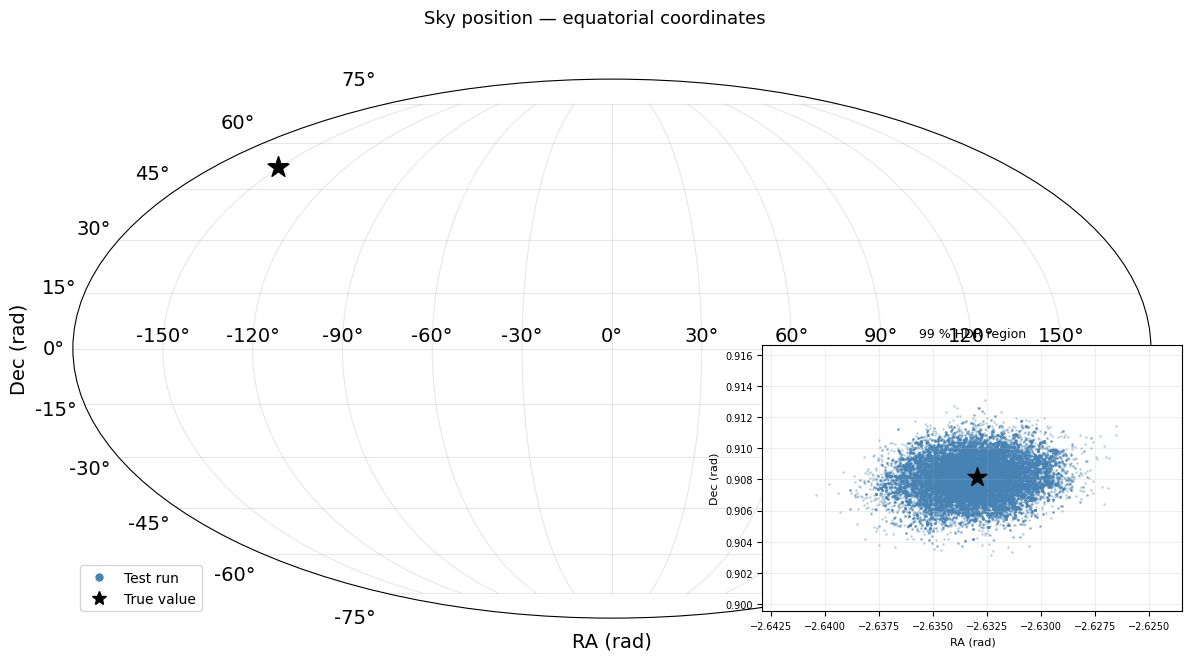

In [21]:
theta_S_true = float(emri['theta_S']) if 'theta_S' in emri else None
phi_S_true   = float(emri['phi_S'])   if 'phi_S'   in emri else None

plot_name_sky = f'{os.getcwd()}/Plots/test_{test_case}_sky_position'

fig = plot_sky_position(
    samples_dict,
    param_names,
    true_theta_S=theta_S_true,
    true_phi_S=phi_S_true,
    plot_name=plot_name_sky,
)

## Convergence tests

The following plots track the running marginal variance (diagonal of the sample covariance) as a function of iteration.
In the ideal case, the plot shapes would have the following characteristics:
1. Rises from zero as walkers spread from their starting points                                                                                     2. Passes through a rapid-growth phase during burn-in (We should have filtered this phase during the earlier inspiral)
3. Flattens into a stable plateau: the dashed line (`var[-1]`) should coincide with where the curve stopped changing                                 4. No systematic drift, no sudden jumps in the last iterations for all parameters.                                                                                                
Convergence criteria.                                                                                                                               - The curve has plateaued (zero or near-zero slope in the tail) for all parameters                                                                   
- The dashed asymptote is reached well before the end of the run. If the curve is still rising at the end, more iterations are needed               
- Sudden jumps indicate a walker discovered a new mode late so the variance will then settle to a new plateau, which is fine as long as R-hat also converges.
- A flat curve at a very small value from the start means walkers are stuck (dead sampler issue, no convergence)   

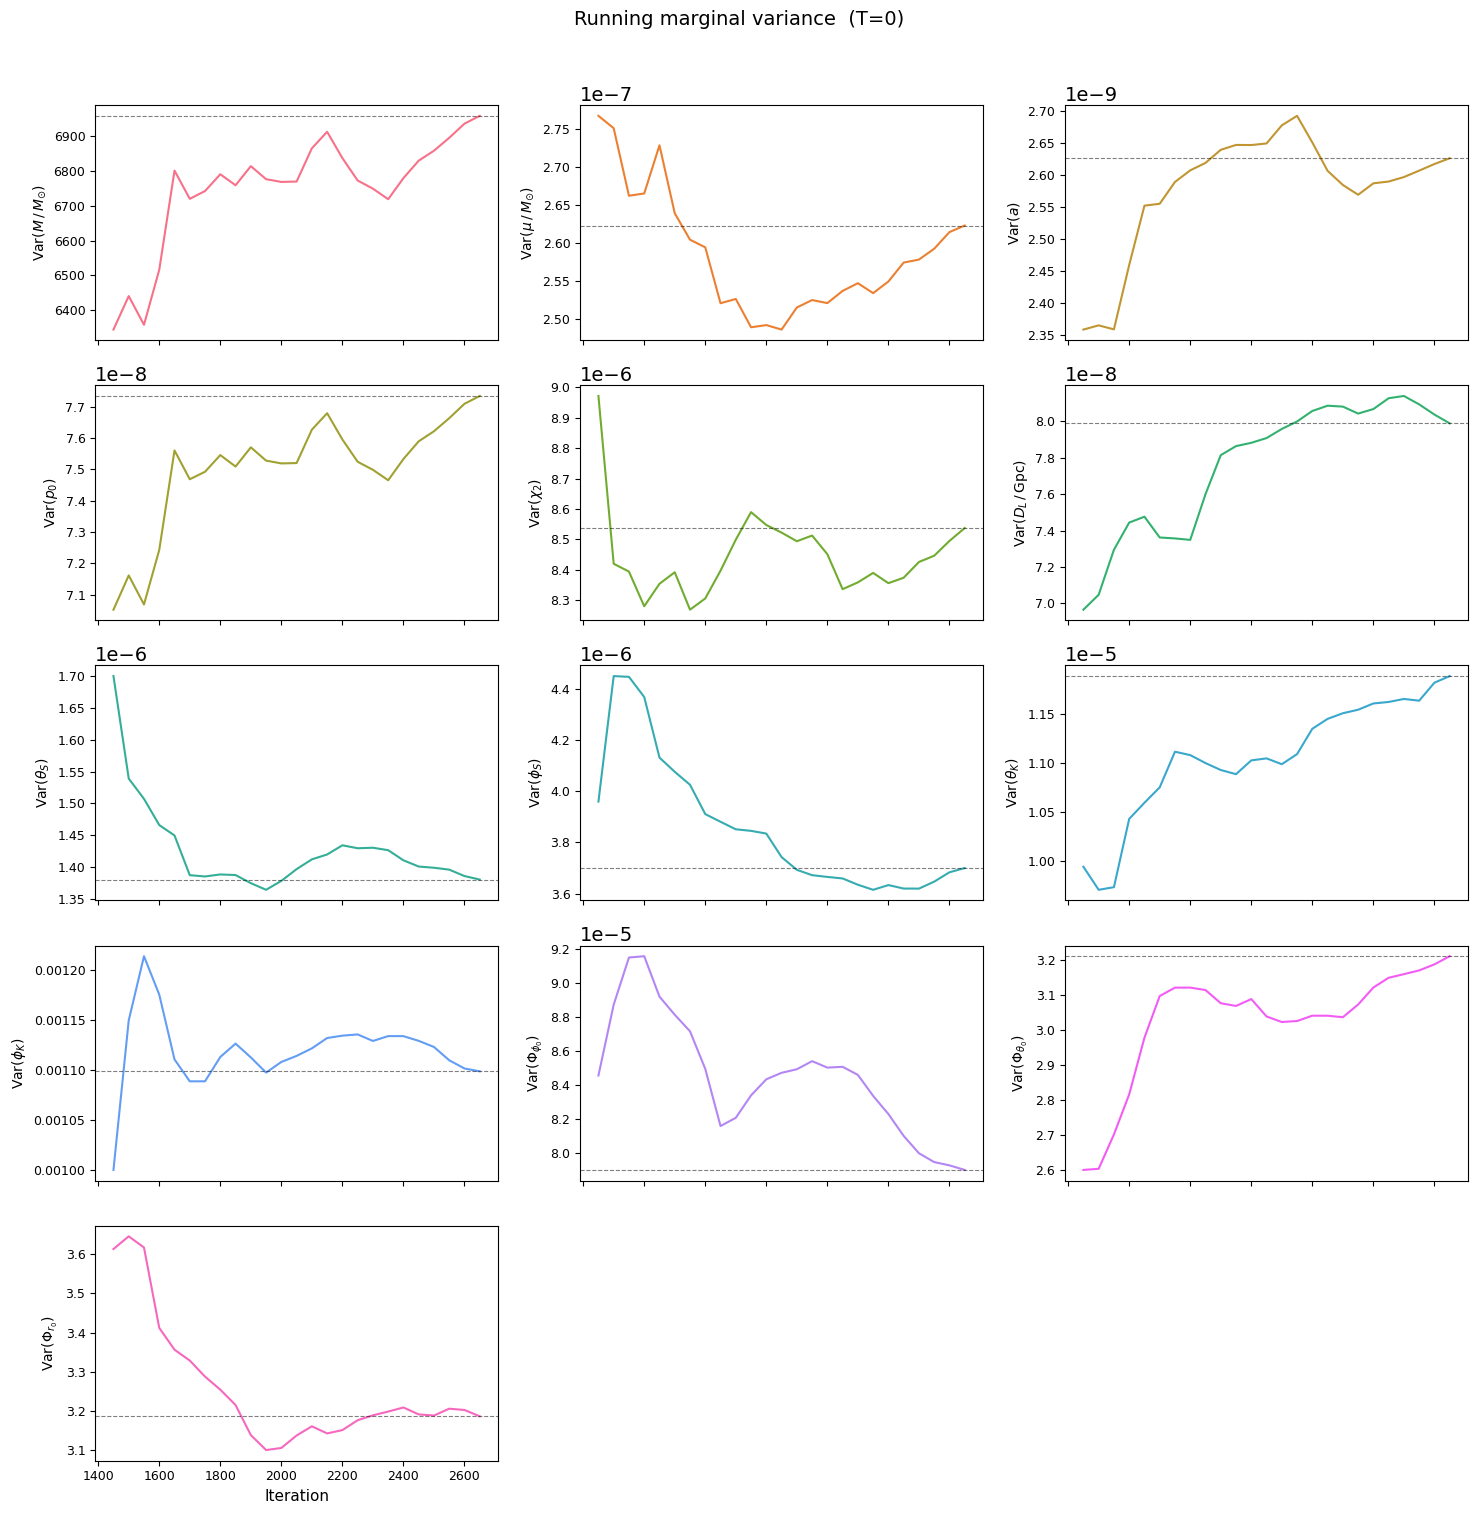

In [22]:
plot_name_cov = f'{os.getcwd()}/Plots/test_{test_case}_covariance'

fig = plot_covariance_evolution(
    reader, param_names,
    discard=discard, temp=0, step=50,
    plot_name=plot_name_cov,
)

We can look at the Gelman-Rubin criterion for convergence. R-hat compares between-chain variance to within-chain variance across walkers. Formally, for M walkers of length N:                                          

- $W   = \text{mean of within-walker variances}$                                                                                                     
- $B   = N/(M-1) * \Sigma (\mu_m - \mu)^2$ -> varaince between difference walkers    
- $\hat{V}   = (N-1)/N * W + B/N   $                                                                                                                 - $\hat{R}   = sqrt(\hat{V} / W)$                                                                                                                                                                   
If all walkers have converged to the same posterior, B/W goes to 1, so R-hat goes to 1. Early on, walkers sample different regions and B >> W, giving R-hat >> 1.                               
                  
In the ideal case, the function `plot_gelman_rubin` computes this running at some intermediate checkpoints:                                                                                    
1. Starts high (commonly 1.1–2+) as walkers haven't mixed                                                                                           
2. Drops monotonically and rapidly during the mixing phase (from parallel tempering)
3. Plateaus and stabilises below the threshold dashed line (default convergence_threshold=1.01, this is a common value for rather strict analysis)   
4. The grey dotted line at 1.0 is the theoretical floor and so the curve should asymptotes towards this value. If it dips below, something went wrong and we need to check.                                                                    
                                                                                                                                                     #### Convergence criterion                                 
We combine the variance evolution of the diagonal elemnts as a function of iteration with the Gelman-Rubin criterion to assess whether the run has concluded or not. All parameters must simultaneously satisfy R-hat < threshold and the curve must be flat a transient dip followed by a rise means the chain is still exploring. The standard rule of thumb is R-hat < 1.01 (strict) or < 1.1 (lenient). Check that the plateau is stable over the last ~30% of iterations.  

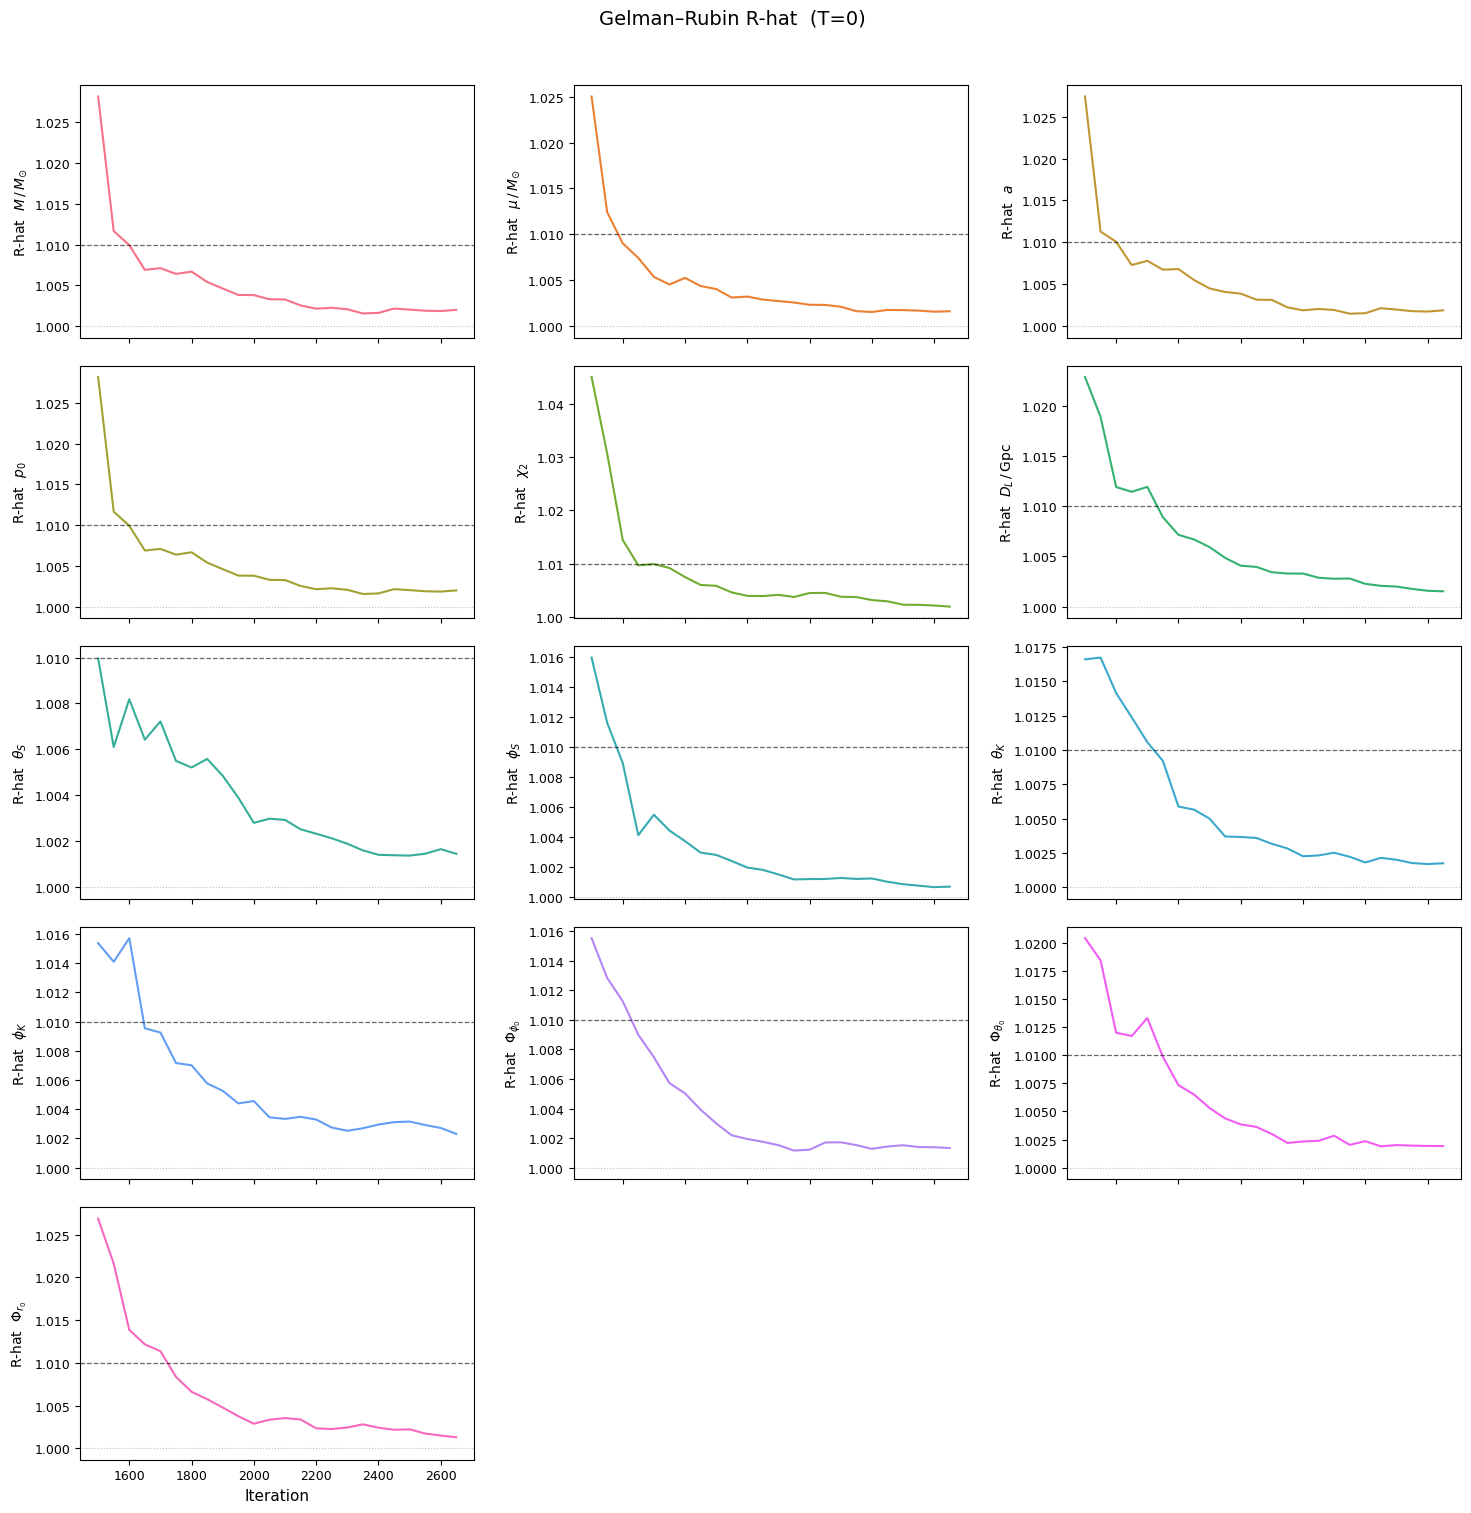

Final R-hat values:
  M                1.0020
  mu               1.0016
  a                1.0019
  p0               1.0020
  chi2             1.0019
  d_L              1.0015
  theta_S          1.0015
  phi_S            1.0007
  theta_K          1.0017
  phi_K            1.0023
  Phi_phi0         1.0013
  Phi_theta0       1.0019
  Phi_r0           1.0013


In [23]:
plot_name_rhat = f'{os.getcwd()}/Plots/test_{test_case}_gelman_rubin'

rhat = plot_gelman_rubin(
    reader, param_names,
    discard=discard, temp=0, step=50,
    convergence_threshold=1.01,
    plot_name=plot_name_rhat,
)
print('Final R-hat values:')
for name, rh in zip(param_names, rhat[-1]):
    print(f'  {name:<16} {rh:.4f}')

## Some extra plots
Use the statistical tools in seaborn to inspect properties of the inferred posterior distributions, such as skewness, multimodality, etc. This can help identify potential issues with the sampling process or the model fit.

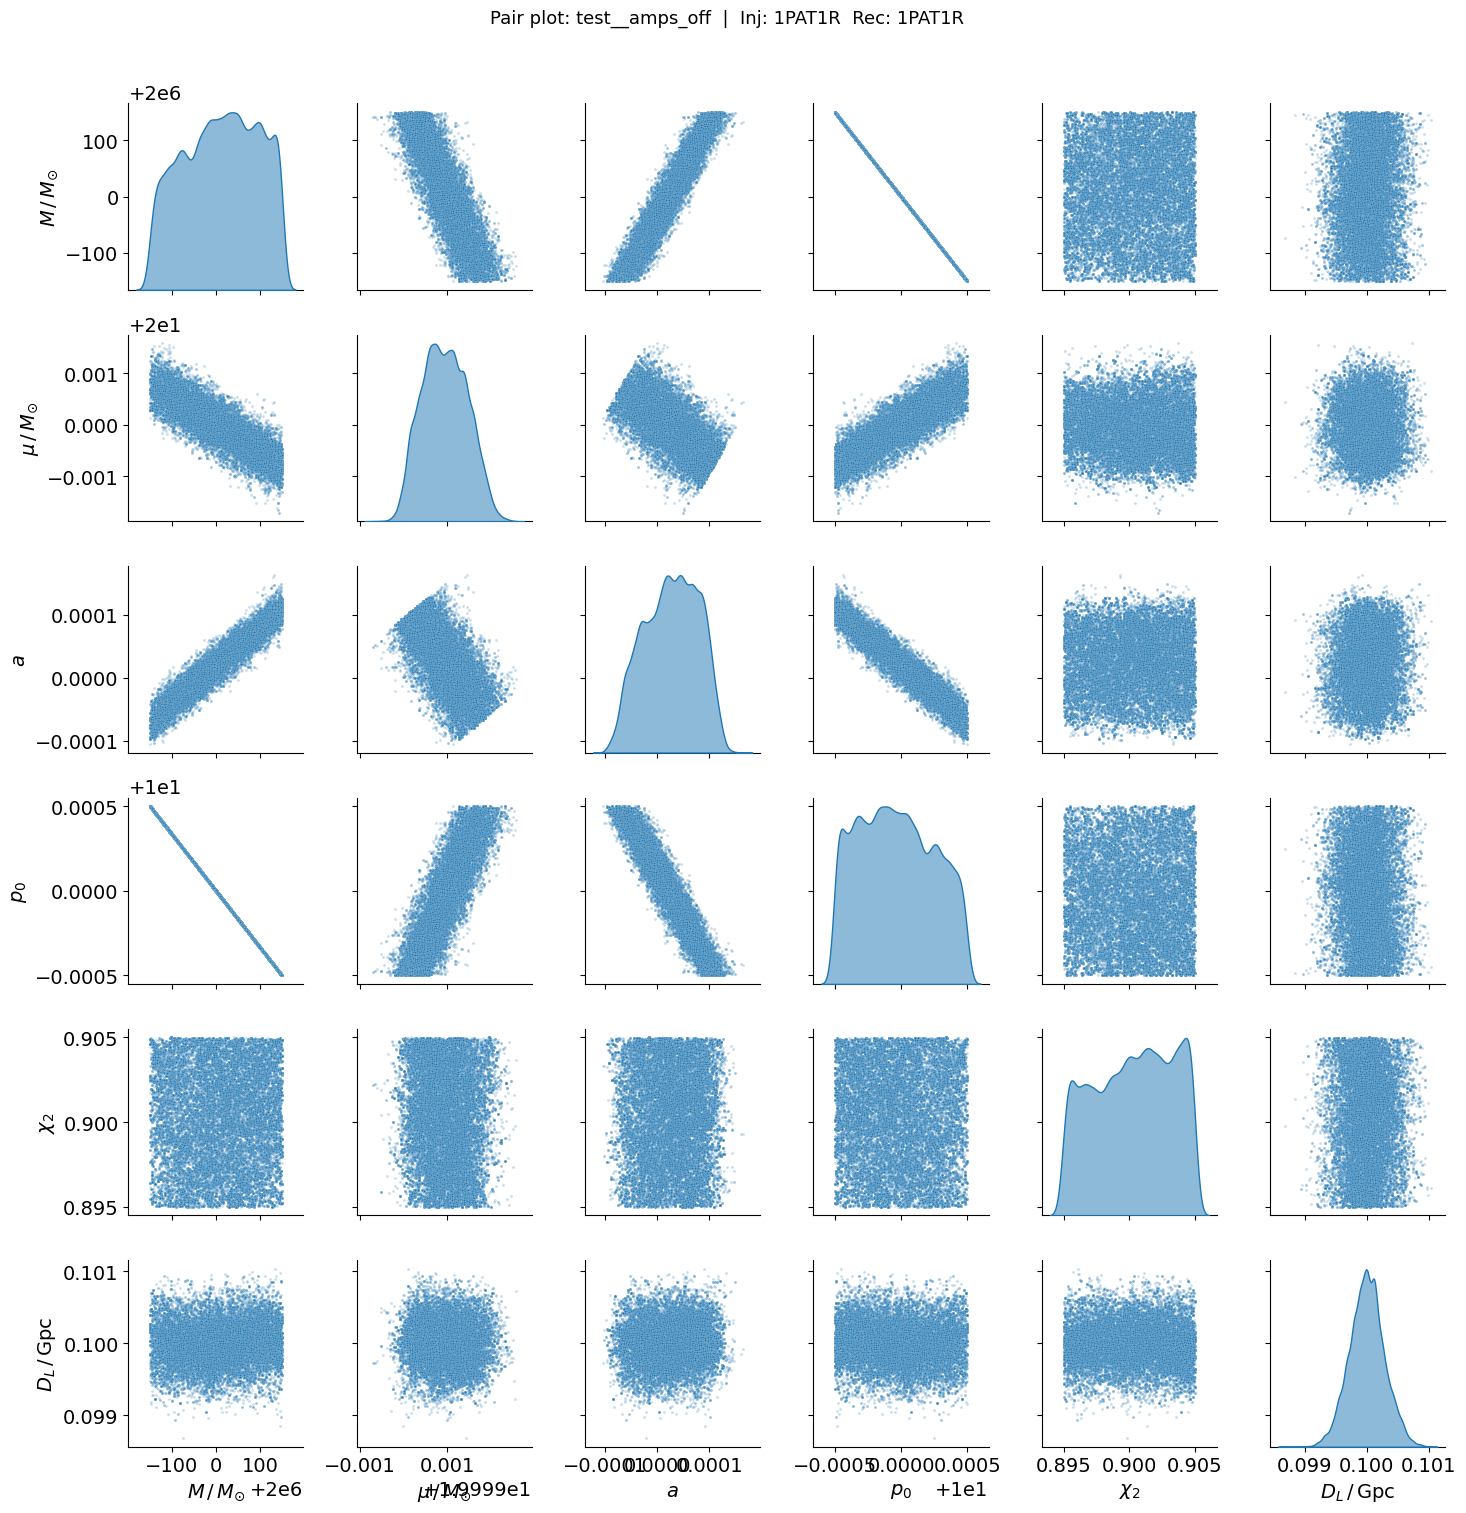

/vsc-hard-mounts/leuven-data/367/vsc36785/LISA/Few_1PAT1R_Scripts/validation/PE_test_runs/src/analysis.py:852: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


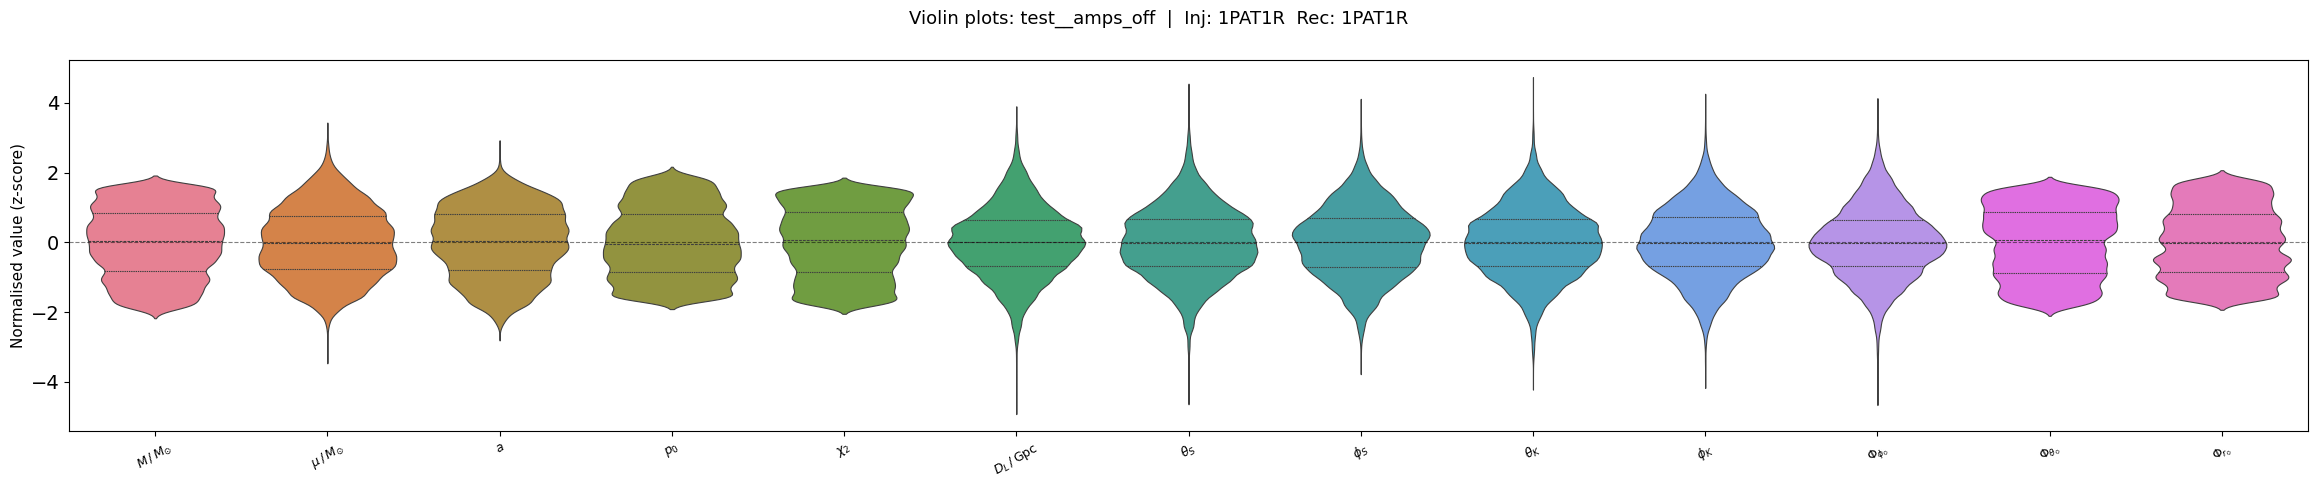

In [24]:
plot_name_sb = f'{os.getcwd()}/Plots/test_{test_case}_seaborn'

title = (
    f'test_{test_case}  |  '
    f"Inj: {inj_wf['model']}  Rec: {rec_wf['model']}"
)

fig = plot_seaborn_diagnostics(
    samples_per_temp[0],
    param_names,
    title=title,
    max_pair_params=6,
    plot_name=plot_name_sb,
)